# 03 - Algorithm Analysis & Two-Layer Clustering

Este notebook analiza **TODO el universo de algoritmos** (~14,761) usando un enfoque de clustering de dos capas.

## Enfoque de Dos Capas

**Capa 1: Life Profile (Perfil de Vida)**
- Â¿CuÃ¡ndo empieza el algoritmo?
- Â¿CuÃ¡nto dura?
- Â¿Tiene gaps de actividad?

**Capa 2: Financial Behavior (Comportamiento Financiero)**
- Dentro de cada grupo de vida, Â¿cÃ³mo se comporta?
- Â¿Es rentable? Â¿VolÃ¡til? Â¿Estable?
- Â¿Mejora o empeora con el tiempo?

## Por quÃ© dos capas?
No tiene sentido comparar directamente un algoritmo que vive todo el estudio con otro que solo dura 3 semanas. Son contextos diferentes.

## Features Mejoradas

| Bloque | Features | DescripciÃ³n |
|--------|----------|-------------|
| Actividad | start_idx, duration_ratio, active_ratio, n_gaps | PatrÃ³n temporal de vida |
| Rendimiento | sharpe, sortino, max_dd, ulcer_index, hit_ratio | Performance financiera |
| TransiciÃ³n | return_decay, sharpe_decay, time_to_first_dd | EvoluciÃ³n con la edad |
| Benchmark | corr_benchmark, beta, alpha, tracking_error | RelaciÃ³n con benchmark |

## Output
- `notebooks/data/algo_features_enhanced.parquet`: Features completas
- `notebooks/data/algo_clusters_twolayer.parquet`: Clusters de dos capas
- `notebooks/data/clustering_methods_comparison.csv`: ComparaciÃ³n de mÃ©todos

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy import stats

from src.data.loader import DataLoader
from src.data.preprocessor import DataPreprocessor
from src.analysis.algo_features import (
    AlgoFeatureExtractor,
    AlgoFeatureConfig,
    ACTIVITY_FEATURES,
    PERFORMANCE_FEATURES,
    TRANSITION_FEATURES,
    BENCHMARK_FEATURES,
)
from src.analysis.algo_clusterer import (
    AlgoClusterer,
    ClusterMethod,
    ScalerType,
    name_clusters,
)
from src.utils.logging_utils import setup_logging

setup_logging(level='INFO')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Cargar Datos

In [2]:
from src.utils.paths import data_paths
from notebook_paths import notebook_data_path
dp = data_paths()

# Cargar datos
loader = DataLoader(str(dp.raw.root))
preprocessor = DataPreprocessor(initial_capital=100, resample_freq='D')

# Benchmark
benchmark_raw = loader.load_benchmark()
benchmark = preprocessor.process_benchmark(benchmark_raw)

# Lista de algoritmos en el benchmark
benchmark_algo_ids = set(benchmark.products)
print(f"Algoritmos en benchmark: {len(benchmark_algo_ids)}")

# Cargar TODOS los algoritmos (no solo los del benchmark)
print("\nCargando TODOS los algoritmos...")
all_algo_ids = loader.list_algorithms()
print(f"Total algoritmos disponibles: {len(all_algo_ids)}")

# Cargar en batches para evitar problemas de memoria
all_algorithms = loader.load_all_algorithms(algo_ids=all_algo_ids, show_progress=True)
processed_all_algos = preprocessor.process_all_algorithms(all_algorithms, show_progress=True)

# Matriz de retornos de TODOS los algoritmos
returns_matrix_all = preprocessor.create_returns_matrix(processed_all_algos)

# TambiÃ©n necesitamos los del benchmark para calcular benchmark returns
processed_benchmark_algos = {k: v for k, v in processed_all_algos.items() if k in benchmark_algo_ids}
returns_matrix_benchmark = preprocessor.create_returns_matrix(processed_benchmark_algos)

benchmark_daily_returns = preprocessor.calculate_benchmark_daily_returns(
    returns_matrix_benchmark, benchmark.weights
)

print(f"\n{'='*60}")
print(f"RESUMEN DE DATOS")
print(f"{'='*60}")
print(f"Total algoritmos procesados: {len(processed_all_algos)}")
print(f"Algoritmos en benchmark: {len(benchmark_algo_ids)}")
print(f"Matriz ALL: {returns_matrix_all.shape}")
print(f"Rango fechas: {returns_matrix_all.index.min()} -> {returns_matrix_all.index.max()}")


RESUMEN DE DATOS
Total algoritmos procesados: 13513
Algoritmos en benchmark: 271
Matriz ALL: (1430, 13513)
Rango fechas: 2020-06-02 00:00:00 -> 2024-12-30 00:00:00


---
## 2. Feature Engineering Avanzado
---

Extraemos features en 4 bloques:
1. **Actividad**: PatrÃ³n temporal de vida
2. **Rendimiento**: MÃ©tricas financieras
3. **TransiciÃ³n**: EvoluciÃ³n con la edad
4. **Benchmark**: RelaciÃ³n con el benchmark

In [3]:
# Configurar extractor de features
config = AlgoFeatureConfig(
    min_active_days=60,      # MÃ­nimo 60 dÃ­as activos
    tercile_split=True,      # Dividir vida en tercios
    compute_autocorr=True,   # Calcular autocorrelaciones
    dd_threshold=0.05,       # Umbral para primer drawdown relevante (5%)
)

extractor = AlgoFeatureExtractor(config)

print("Extrayendo features avanzadas...")
print(f"  - Features de actividad: {ACTIVITY_FEATURES}")
print(f"  - Features de rendimiento: {PERFORMANCE_FEATURES}")
print(f"  - Features de transiciÃ³n: {TRANSITION_FEATURES}")
print(f"  - Features vs benchmark: {BENCHMARK_FEATURES}")

# Extraer features
algo_features = extractor.extract_all_features(
    returns_matrix_all,
    benchmark_returns=benchmark_daily_returns
)

# AÃ±adir flag indicando si estÃ¡ en el benchmark
algo_features['in_benchmark'] = algo_features.index.isin(benchmark_algo_ids)

print(f"\n{'='*60}")
print(f"FEATURES EXTRAÃDAS")
print(f"{'='*60}")
print(f"Total algoritmos con suficientes datos: {len(algo_features)}")
print(f"  - En benchmark: {algo_features['in_benchmark'].sum()}")
print(f"  - Fuera de benchmark: {(~algo_features['in_benchmark']).sum()}")
print(f"\nTotal features: {len(algo_features.columns)}")
print(f"Columns: {list(algo_features.columns)}")


FEATURES EXTRAÃDAS
Total algoritmos con suficientes datos: 7200
  - En benchmark: 257
  - Fuera de benchmark: 6943

Total features: 48
Columns: ['start_idx', 'end_idx', 'duration_ratio', 'active_ratio', 'n_gaps', 'gap_ratio', 'n_active_days', 'total_return', 'ann_return', 'ann_vol', 'sharpe', 'sortino', 'max_dd', 'ulcer_index', 'var_95', 'cvar_95', 'skewness', 'kurtosis', 'hit_ratio', 'profit_factor', 'best_streak', 'worst_streak', 'equity_slope', 'equity_r2', 'return_first_third', 'return_middle_third', 'return_last_third', 'vol_first_third', 'vol_last_third', 'sharpe_first_third', 'sharpe_last_third', 'return_decay', 'sharpe_decay', 'vol_change', 'sharpe_stability', 'return_stability', 'time_to_first_dd', 'autocorr_1', 'autocorr_5', 'early_return', 'early_sharpe', 'corr_benchmark', 'beta', 'alpha', 'trend_score', 'tracking_error', 'info_ratio', 'in_benchmark']


In [4]:
# Vista previa de features
print("\nMuestra de features:")
display(algo_features.head(10))

,start_idx,end_idx,duration_ratio,active_ratio,n_gaps,gap_ratio,n_active_days,total_return,ann_return,ann_vol,sharpe,sortino,max_dd,ulcer_index,var_95,cvar_95,skewness,kurtosis,hit_ratio,profit_factor,best_streak,worst_streak,equity_slope,equity_r2,return_first_third,return_middle_third,return_last_third,vol_first_third,vol_last_third,sharpe_first_third,sharpe_last_third,return_decay,sharpe_decay,vol_change,sharpe_stability,return_stability,time_to_first_dd,autocorr_1,autocorr_5,early_return,early_sharpe,corr_benchmark,beta,alpha,trend_score,tracking_error,info_ratio,in_benchmark
algo_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
007XY,0.394406,0.466434,0.072727,0.615385,6,0.384615,64,-0.106252,-0.435244,0.116452,-3.737538,-6.059110,-0.099720,0.050016,-0.012808,-0.014034,0.454474,0.332438,0.343750,0.544513,6,6,-0.265730,0.638443,-0.714228,0.206235,-0.781262,0.124695,0.075104,-5.727784,-10.402430,-0.067034,-4.674645,-0.049592,0.249852,2.627839,0.234375,-0.055725,0.114546,-0.714228,-5.727784,-0.094551,-0.484235,-0.429941,-0.067486,0.120743,-3.695418,False
00lLe,0.000000,0.377622,0.378322,0.883549,21,0.116451,478,-0.277374,-0.161250,0.141223,-1.141808,-1.561255,-0.324266,0.164463,-0.014507,-0.020607,0.055254,8.151579,0.426778,0.795688,8,9,-0.115666,0.743201,-0.207522,0.007426,-0.282889,0.120514,0.177216,-1.721984,-1.596296,-0.075366,0.125687,0.056702,0.262496,2.059724,0.182008,0.087547,-0.007550,0.007778,0.238116,-0.088885,-0.414217,-0.152089,0.012237,0.147203,-1.242370,False
00ufq,0.208392,0.302797,0.095105,0.830882,14,0.169118,113,0.001612,0.011541,0.126540,0.091204,0.122708,-0.112916,0.032829,-0.011277,-0.019841,-0.283395,2.276462,0.460177,1.016765,4,7,0.152425,0.221553,0.254971,0.429236,-0.615680,0.107204,0.142467,2.378367,-4.321571,-0.870651,-6.699939,0.035263,0.239301,1.834724,0.911504,0.259975,0.013923,0.228892,2.377990,-0.176076,-0.823137,0.052340,0.033194,0.133982,-0.283800,False
00Zqs,0.468531,0.927972,0.460140,0.527356,33,0.472644,347,-0.031740,-0.017904,0.104957,-0.170585,-0.173028,-0.165740,0.072368,-0.010550,-0.018678,-1.047217,9.040808,0.628242,0.965674,13,5,-0.007129,0.002132,0.200449,0.120702,-0.368761,0.090899,0.139837,2.205194,-2.637071,-0.569210,-4.842266,0.048939,0.249442,2.222439,0.706052,-0.043576,0.021942,-0.072751,-0.744629,0.103889,0.473060,-0.035867,-0.075987,0.105093,-0.531691,False
01wS7,0.013986,0.846154,0.832867,0.247691,33,0.752309,295,-0.138979,-0.121866,0.108839,-1.119690,-1.293090,-0.187126,0.111209,-0.011069,-0.019322,-0.758475,6.035665,0.488136,0.798317,7,8,-0.108829,0.742639,-0.238499,-0.118993,-0.009254,0.129205,0.084551,-1.845894,-0.109444,0.229245,1.736450,-0.044654,0.309477,2.866175,0.077966,0.131901,-0.051575,-0.465847,-1.929894,0.062441,0.208951,-0.130144,0.083025,0.111632,-1.446596,False
02IV7,0.827972,0.999301,0.172028,0.930894,8,0.069106,229,-0.028376,-0.016298,0.175264,-0.092993,-0.107950,-0.161041,0.085806,-0.019188,-0.028940,-0.697058,5.060238,0.563319,0.982294,9,6,-0.037402,0.062089,0.338581,-0.228549,-0.157074,0.187373,0.139322,1.806990,-1.127420,-0.495655,-2.934411,-0.048051,0.300695,1.980859,0.157205,0.024903,-0.085053,0.172399,1.223786,0.464375,2.817295,-0.154701,0.018156,0.163858,-0.399274,False
02Ptt,0.573427,0.999301,0.426573,0.967213,19,0.032787,590,0.081213,0.038591,0.102279,0.377307,0.460169,-0.122239,0.050534,-0.010724,-0.016453,-0.714604,5.090857,0.562712,1.071262,8,7,0.051780,0.416842,-0.057434,0.118871,0.054176,0.118449,0.083190,-0.484883,0.651229,0.111610,1.136112,-0.035259,0.307270,3.051044,0.086441,0.094135,-0.017308,0.236222,5.016702,0.128963,0.510899,0.026473,-0.018140,0.102208,0.145515,False
038uO,0.000000,0.223077,0.223776,0.987500,4,0.012500,316,0.156839,0.121669,0.104533,1.163936,1.171306,-0.076075,0.019213,-0.010707,-0.016823,-0.534456,15.585903,0.661392,1.290833,14,5,0.131301,0.831039,0.081974,0.206161,0.077295,0.071680,0.155736,1.143610,0.496321,-0.004679,-0.647289,0.084056,0.264729,3.608344,0.705696,-0.106871,-0.081265,0.071262,1.562699,-0.039163,-

In [5]:
# EstadÃ­sticas descriptivas por bloque
print("\n" + "="*80)
print("ESTADÃSTICAS POR BLOQUE DE FEATURES")
print("="*80)

blocks = {
    'Actividad': ACTIVITY_FEATURES,
    'Rendimiento': PERFORMANCE_FEATURES,
    'TransiciÃ³n': TRANSITION_FEATURES,
    'Benchmark': BENCHMARK_FEATURES,
}

for block_name, features in blocks.items():
    available = [f for f in features if f in algo_features.columns]
    if available:
        print(f"\n{block_name}:")
        display(algo_features[available].describe().T.style.format('{:.3f}'))

,count,mean,std,min,25%,50%,75%,max
corr_benchmark,7200.000,0.039,0.136,-0.655,-0.042,0.032,0.109,0.672
beta,7200.000,0.173,0.687,-5.079,-0.175,0.135,0.473,5.796
alpha,7200.000,-0.090,0.169,-1.424,-0.165,-0.062,0.013,0.644
trend_score,7200.000,-0.000,0.076,-0.516,-0.042,0.000,0.041,0.425
tracking_error,7200.000,0.131,0.038,0.031,0.108,0.126,0.148,0.804
info_ratio,7200.000,-0.822,1.208,-7.948,-1.464,-0.688,-0.064,7.462


---
## 3. AnÃ¡lisis de Features de Actividad (Life Profile)
---

Â¿CÃ³mo se distribuyen los patrones de vida de los algoritmos?

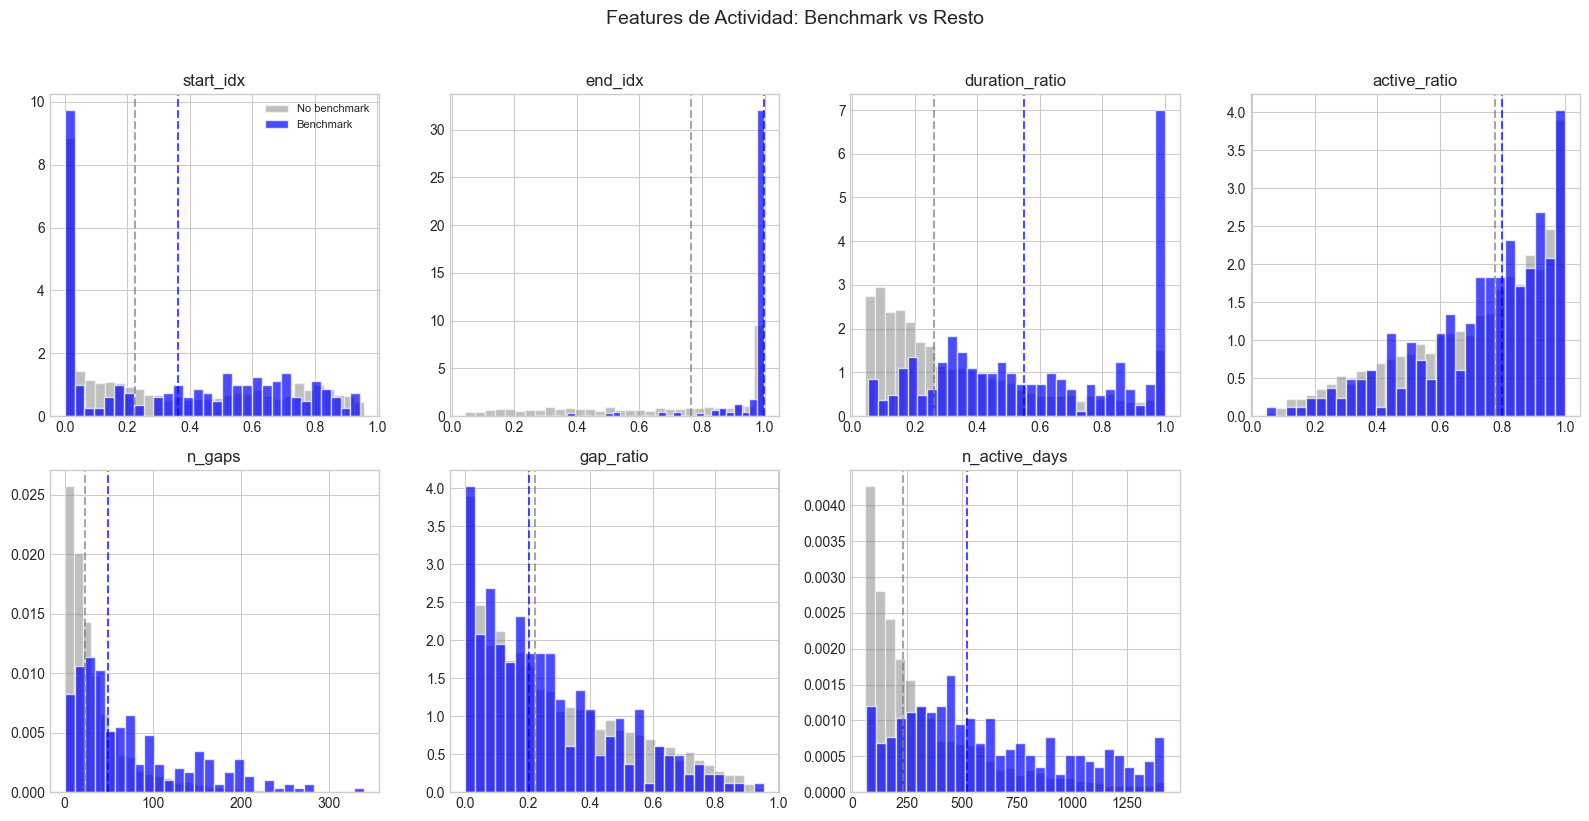

In [6]:
# Visualizar distribuciÃ³n de features de actividad
activity_features = [f for f in ACTIVITY_FEATURES if f in algo_features.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(activity_features[:8]):
    ax = axes[i]
    
    # Separar benchmark vs no benchmark
    in_bench = algo_features[algo_features['in_benchmark']][col]
    not_in_bench = algo_features[~algo_features['in_benchmark']][col]
    
    ax.hist(not_in_bench, bins=30, alpha=0.5, color='gray', label='No benchmark', density=True)
    ax.hist(in_bench, bins=30, alpha=0.7, color='blue', label='Benchmark', density=True)
    
    ax.axvline(not_in_bench.median(), color='gray', linestyle='--', alpha=0.7)
    ax.axvline(in_bench.median(), color='blue', linestyle='--', alpha=0.7)
    
    ax.set_title(col)
    if i == 0:
        ax.legend(fontsize=8)

for i in range(len(activity_features), 8):
    axes[i].set_visible(False)

plt.suptitle('Features de Actividad: Benchmark vs Resto', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Scatter plot: start_idx vs duration_ratio
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Start vs Duration
ax1 = axes[0]
not_bench = algo_features[~algo_features['in_benchmark']]
bench = algo_features[algo_features['in_benchmark']]

ax1.scatter(not_bench['start_idx'], not_bench['duration_ratio'], 
           c='lightgray', s=10, alpha=0.3, label=f'No benchmark ({len(not_bench)})')
ax1.scatter(bench['start_idx'], bench['duration_ratio'], 
           c='blue', s=30, alpha=0.7, label=f'Benchmark ({len(bench)})')

ax1.set_xlabel('Start Index (0=inicio, 1=fin del estudio)')
ax1.set_ylabel('Duration Ratio (proporciÃ³n del estudio)')
ax1.set_title('Â¿CuÃ¡ndo empiezan y cuÃ¡nto duran?')
ax1.legend()

# Plot 2: Duration vs Active Ratio
ax2 = axes[1]
ax2.scatter(not_bench['duration_ratio'], not_bench['active_ratio'], 
           c='lightgray', s=10, alpha=0.3)
ax2.scatter(bench['duration_ratio'], bench['active_ratio'], 
           c='blue', s=30, alpha=0.7)

ax2.set_xlabel('Duration Ratio')
ax2.set_ylabel('Active Ratio (% tiempo activo sobre duraciÃ³n)')
ax2.set_title('Â¿Son continuos o tienen gaps?')

plt.tight_layout()
plt.show()

# InterpretaciÃ³n
print("\nInterpretaciÃ³n:")
print(f"  - Algoritmos del benchmark: start_idx medio = {bench['start_idx'].mean():.2f}")
print(f"  - Algoritmos del benchmark: duration_ratio medio = {bench['duration_ratio'].mean():.2f}")
print(f"  - Algoritmos fuera: start_idx medio = {not_bench['start_idx'].mean():.2f}")
print(f"  - Algoritmos fuera: duration_ratio medio = {not_bench['duration_ratio'].mean():.2f}")


InterpretaciÃ³n:
  - Algoritmos del benchmark: start_idx medio = 0.36
  - Algoritmos del benchmark: duration_ratio medio = 0.59
  - Algoritmos fuera: start_idx medio = 0.33
  - Algoritmos fuera: duration_ratio medio = 0.36


---
## 4. AnÃ¡lisis de Features de TransiciÃ³n
---

Â¿CÃ³mo evoluciona el rendimiento con la edad del algoritmo?

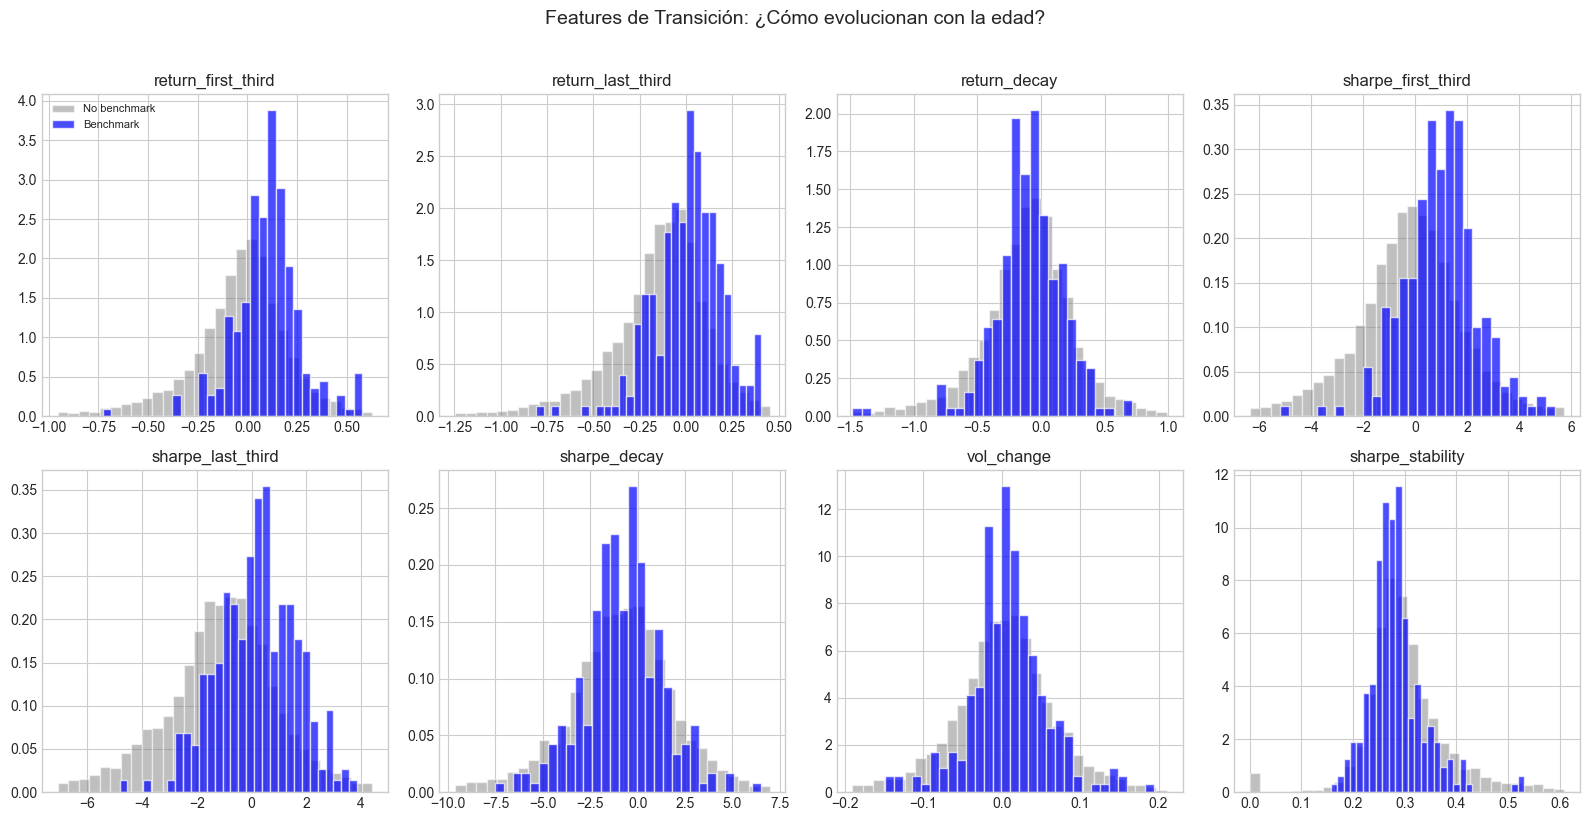

In [8]:
# Visualizar features de transiciÃ³n
transition_features = [f for f in TRANSITION_FEATURES if f in algo_features.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(transition_features[:8]):
    ax = axes[i]
    
    in_bench = algo_features[algo_features['in_benchmark']][col]
    not_in_bench = algo_features[~algo_features['in_benchmark']][col]
    
    # Eliminar outliers extremos para visualizaciÃ³n
    q_low, q_high = not_in_bench.quantile([0.01, 0.99])
    filtered_not = not_in_bench[(not_in_bench >= q_low) & (not_in_bench <= q_high)]
    filtered_in = in_bench[(in_bench >= q_low) & (in_bench <= q_high)]
    
    ax.hist(filtered_not, bins=30, alpha=0.5, color='gray', label='No benchmark', density=True)
    ax.hist(filtered_in, bins=30, alpha=0.7, color='blue', label='Benchmark', density=True)
    
    ax.set_title(col)
    if i == 0:
        ax.legend(fontsize=8)

for i in range(len(transition_features), 8):
    axes[i].set_visible(False)

plt.suptitle('Features de TransiciÃ³n: Â¿CÃ³mo evolucionan con la edad?', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# AnÃ¡lisis de degradaciÃ³n: Â¿Los algoritmos mejoran o empeoran?
print("\n" + "="*60)
print("ANÃLISIS DE DEGRADACIÃ“N")
print("="*60)

# Clasificar algoritmos por degradaciÃ³n
if 'return_decay' in algo_features.columns:
    improving = (algo_features['return_decay'] > 0.05).sum()
    stable = ((algo_features['return_decay'] >= -0.05) & (algo_features['return_decay'] <= 0.05)).sum()
    degrading = (algo_features['return_decay'] < -0.05).sum()
    
    print(f"\nDistribuciÃ³n de degradaciÃ³n (return_decay):")
    print(f"  - Mejorando (>5%): {improving} ({improving/len(algo_features)*100:.1f}%)")
    print(f"  - Estable (Â±5%): {stable} ({stable/len(algo_features)*100:.1f}%)")
    print(f"  - Degradando (<-5%): {degrading} ({degrading/len(algo_features)*100:.1f}%)")
    
    # Comparar benchmark vs no benchmark
    bench_decay = algo_features[algo_features['in_benchmark']]['return_decay'].mean()
    non_bench_decay = algo_features[~algo_features['in_benchmark']]['return_decay'].mean()
    
    print(f"\n  Return decay medio (benchmark): {bench_decay:.4f}")
    print(f"  Return decay medio (no benchmark): {non_bench_decay:.4f}")

# Tiempo hasta primer drawdown
if 'time_to_first_dd' in algo_features.columns:
    print(f"\nTiempo hasta primer drawdown relevante (>5%):")
    print(f"  - Benchmark: {algo_features[algo_features['in_benchmark']]['time_to_first_dd'].mean():.2f}")
    print(f"  - No benchmark: {algo_features[~algo_features['in_benchmark']]['time_to_first_dd'].mean():.2f}")
    print(f"  (1.0 = nunca tuvo DD relevante durante su vida)")


ANÃLISIS DE DEGRADACIÃ“N

DistribuciÃ³n de degradaciÃ³n (return_decay):
  - Mejorando (>5%): 2258 (31.4%)
  - Estable (Â±5%): 1008 (14.0%)
  - Degradando (<-5%): 3934 (54.6%)

  Return decay medio (benchmark): -0.0811
  Return decay medio (no benchmark): -0.1121

Tiempo hasta primer drawdown relevante (>5%):
  - Benchmark: 0.26
  - No benchmark: 0.31
  (1.0 = nunca tuvo DD relevante durante su vida)


---
## 5. Test EstadÃ­stico: Benchmark vs No-Benchmark
---

In [10]:
# Test de Mann-Whitney U para todas las features
print("="*80)
print("TEST DE MANN-WHITNEY U: Â¿QuÃ© distingue al benchmark?")
print("="*80)

all_test_features = (
    ACTIVITY_FEATURES + PERFORMANCE_FEATURES + 
    TRANSITION_FEATURES + BENCHMARK_FEATURES
)
all_test_features = [f for f in all_test_features if f in algo_features.columns]

results = []
for col in all_test_features:
    in_bench = algo_features[algo_features['in_benchmark']][col].dropna()
    not_in_bench = algo_features[~algo_features['in_benchmark']][col].dropna()
    
    if len(in_bench) > 5 and len(not_in_bench) > 5:
        stat, p = stats.mannwhitneyu(in_bench, not_in_bench, alternative='two-sided')
        
        diff = in_bench.median() - not_in_bench.median()
        direction = "â†‘" if diff > 0 else "â†“"
        
        results.append({
            'feature': col,
            'p_value': p,
            'significant': p < 0.05,
            'bench_median': in_bench.median(),
            'non_bench_median': not_in_bench.median(),
            'diff': diff,
            'direction': direction,
        })

results_df = pd.DataFrame(results).sort_values('p_value')

print("\nFeatures mÃ¡s significativas (p<0.05):")
sig_results = results_df[results_df['significant']]
display(sig_results.style.format({
    'p_value': '{:.2e}',
    'bench_median': '{:.4f}',
    'non_bench_median': '{:.4f}',
    'diff': '{:+.4f}',
}))

print(f"\nTotal features significativas: {len(sig_results)} / {len(results)}")


Total features significativas: 28 / 37


---
## 6. Clustering de Dos Capas
---

**Capa 1: Life Profile** - Agrupar por patrÃ³n de actividad
**Capa 2: Financial Behavior** - Dentro de cada grupo, agrupar por rendimiento

In [11]:
# Definir features para cada capa
LIFE_FEATURES = [
    'start_idx', 'end_idx', 'duration_ratio', 'active_ratio', 'n_gaps'
]

BEHAVIOR_FEATURES = [
    'sharpe', 'sortino', 'max_dd', 'ann_vol',
    'return_decay', 'sharpe_stability', 'time_to_first_dd',
    'corr_benchmark', 'hit_ratio'
]

# Filtrar features disponibles
life_features = [f for f in LIFE_FEATURES if f in algo_features.columns]
behavior_features = [f for f in BEHAVIOR_FEATURES if f in algo_features.columns]

print("Features para clustering:")
print(f"  Capa 1 (Life Profile): {life_features}")
print(f"  Capa 2 (Financial Behavior): {behavior_features}")

Features para clustering:
  Capa 1 (Life Profile): ['start_idx', 'end_idx', 'duration_ratio', 'active_ratio', 'n_gaps']
  Capa 2 (Financial Behavior): ['sharpe', 'sortino', 'max_dd', 'ann_vol', 'return_decay', 'sharpe_stability', 'time_to_first_dd', 'corr_benchmark', 'hit_ratio']


In [12]:
# Ejecutar clustering de dos capas
two_layer_result = AlgoClusterer.two_layer_clustering(
    algo_features,
    life_features=life_features,
    behavior_features=behavior_features,
    life_method=ClusterMethod.HDBSCAN,
    behavior_method=ClusterMethod.GMM,
    n_life_clusters=4,
    n_behavior_clusters=3,
    min_cluster_size_for_subclustering=100,
    scaler_type=ScalerType.ROBUST,
)

2026-03-27 16:03:00,675 | INFO     | src.analysis.algo_clusterer | ============================================================


In [13]:
# Resumen de resultados
print("\n" + "="*80)
print("RESUMEN DE CLUSTERING DE DOS CAPAS")
print("="*80)

print(f"\nCapa 1 (Life Profile):")
print(f"  MÃ©todo: {two_layer_result.life_profile_result.method.value}")
print(f"  Clusters: {two_layer_result.life_profile_result.n_clusters}")
print(f"  Silhouette: {two_layer_result.life_profile_result.silhouette:.3f}")
print(f"  Ruido: {two_layer_result.life_profile_result.n_noise}")

print(f"\nNombres de Life Profiles:")
for cluster_id, name in sorted(two_layer_result.life_profile_names.items()):
    size = two_layer_result.life_profile_result.cluster_sizes.get(cluster_id, 0)
    print(f"  {cluster_id}: {name} ({size} algos)")

print(f"\nCapa 2 (Financial Behavior):")
for life_id, beh_result in two_layer_result.behavior_results.items():
    life_name = two_layer_result.life_profile_names.get(life_id, f"L{life_id}")
    if beh_result is not None:
        print(f"  {life_name}: {beh_result.n_clusters} sub-clusters, silhouette={beh_result.silhouette:.3f}")
    else:
        print(f"  {life_name}: cluster Ãºnico (muy pocos algos)")

print(f"\nTotal clusters combinados: {two_layer_result.n_total_clusters}")


RESUMEN DE CLUSTERING DE DOS CAPAS

Capa 1 (Life Profile):
  MÃ©todo: hdbscan
  Clusters: 4
  Silhouette: 0.579
  Ruido: 5036

Nombres de Life Profiles:
  -1: noise (5036 algos)
  0: early_long_persistent (211 algos)
  1: late_short (1387 algos)
  2: early_medium_persistent (99 algos)
  3: early_short_persistent (467 algos)

Capa 2 (Financial Behavior):
  early_long_persistent: 3 sub-clusters, silhouette=0.155
  late_short: 3 sub-clusters, silhouette=0.111
  early_medium_persistent: cluster Ãºnico (muy pocos algos)
  early_short_persistent: 3 sub-clusters, silhouette=0.091

Total clusters combinados: 11


In [14]:
# AÃ±adir labels al dataframe
algo_features['life_cluster'] = two_layer_result.life_profile_result.labels
algo_features['life_cluster_name'] = algo_features['life_cluster'].map(
    two_layer_result.life_profile_names
)
algo_features['combined_cluster'] = two_layer_result.combined_labels

# DistribuciÃ³n de clusters combinados
print("\nDistribuciÃ³n de clusters combinados:")
cluster_dist = algo_features['combined_cluster'].value_counts()
print(cluster_dist)


DistribuciÃ³n de clusters combinados:
combined_cluster
noise                                                            5036
late_short__low_perf_high_risk_volatile_degrading_2               667
late_short__low_perf_high_risk_volatile_degrading                 380
late_short__high_perf_low_risk_stable_degrading                   340
early_short_persistent__high_perf_low_risk_stable_degrading       195
early_short_persistent__low_perf_high_risk_volatile               180
early_long_persistent__low_perf_high_risk_volatile_2              105
early_long_persistent__low_perf_high_risk_volatile                101
early_medium_persistent__Ãºnico                                     99
early_short_persistent__low_perf_high_risk_volatile_degrading      92
early_long_persistent__high_perf_low_risk_stable_degrading          5
Name: count, dtype: int64


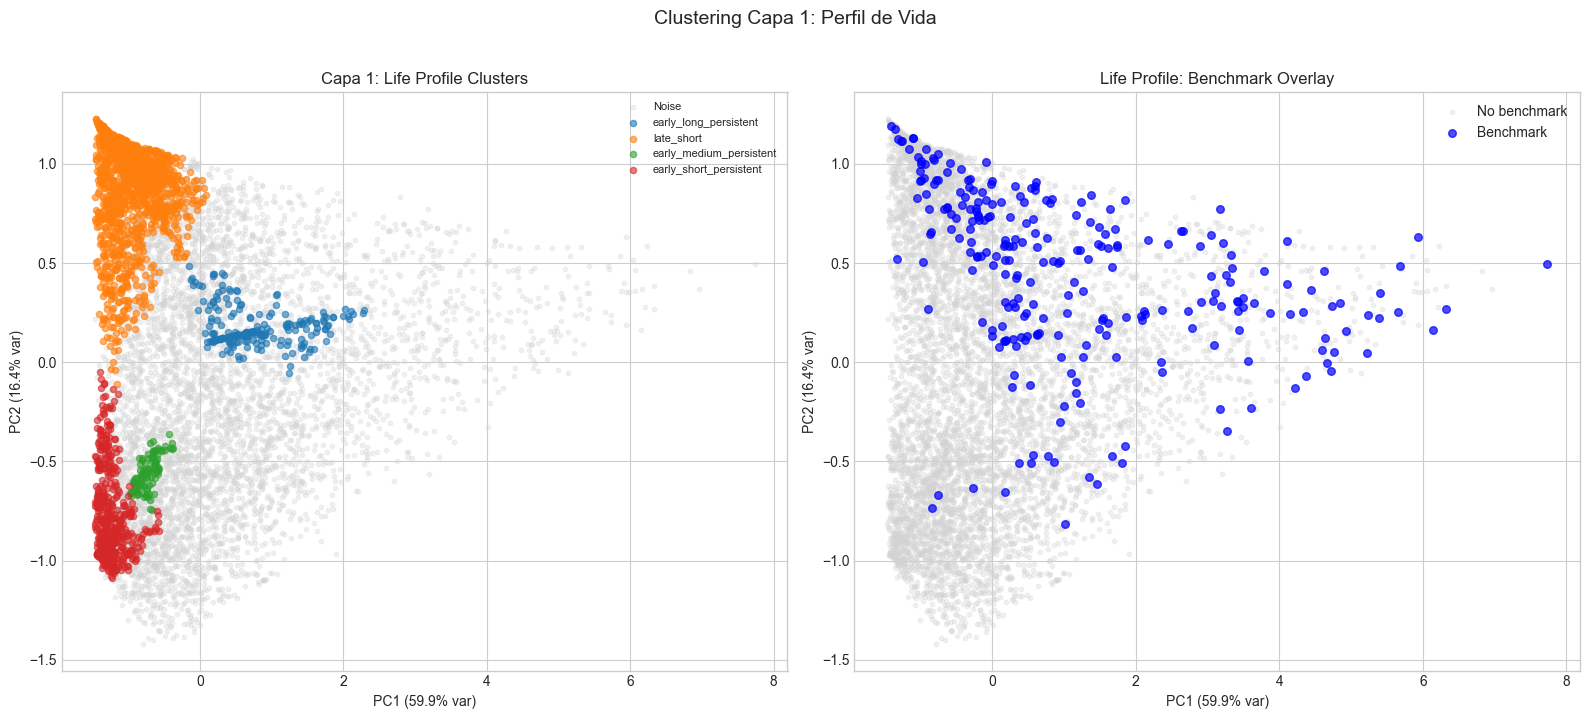

In [15]:
# Visualizar Capa 1 con PCA
X_life = algo_features[life_features].copy()
X_life = X_life.replace([np.inf, -np.inf], np.nan).fillna(X_life.median())

scaler = RobustScaler()
X_life_scaled = scaler.fit_transform(X_life)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_life_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Life clusters
ax1 = axes[0]
labels = two_layer_result.life_profile_result.labels
unique_labels = sorted(set(labels))
colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(unique_labels))))

for i, label in enumerate(unique_labels):
    mask = labels == label
    if label == -1:
        ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c='lightgray', s=10, alpha=0.3, label='Noise')
    else:
        name = two_layer_result.life_profile_names.get(label, f"C{label}")
        ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=[colors[label % 10]], s=20, alpha=0.6, label=name)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax1.set_title('Capa 1: Life Profile Clusters')
ax1.legend(loc='upper right', fontsize=8)

# Plot 2: Benchmark overlay
ax2 = axes[1]
not_bench_mask = ~algo_features['in_benchmark'].values
bench_mask = algo_features['in_benchmark'].values

ax2.scatter(X_pca[not_bench_mask, 0], X_pca[not_bench_mask, 1], 
           c='lightgray', s=10, alpha=0.3, label='No benchmark')
ax2.scatter(X_pca[bench_mask, 0], X_pca[bench_mask, 1], 
           c='blue', s=30, alpha=0.7, label='Benchmark')

ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax2.set_title('Life Profile: Benchmark Overlay')
ax2.legend()

plt.suptitle('Clustering Capa 1: Perfil de Vida', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# Perfil medio de cada Life Cluster
print("\n" + "="*60)
print("PERFIL MEDIO DE CADA LIFE CLUSTER")
print("="*60)

# Filtrar ruido
non_noise = algo_features[algo_features['life_cluster'] >= 0]

life_profiles = non_noise.groupby('life_cluster_name')[life_features + ['sharpe', 'max_dd']].mean()
display(life_profiles.style.format('{:.3f}').background_gradient(cmap='RdYlGn', axis=0))

,start_idx,end_idx,duration_ratio,active_ratio,n_gaps,sharpe,max_dd
life_cluster_name,,,,,,,
early_long_persistent,0.041,0.994,0.955,0.937,41.303,0.000,-0.259
early_medium_persistent,0.006,0.401,0.396,0.974,10.313,-0.456,-0.221
early_short_persistent,0.071,0.173,0.103,0.949,4.934,-1.110,-0.117
late_short,0.769,0.926,0.158,0.893,12.055,-0.379,-0.123


---
## 7. AnÃ¡lisis de RepresentaciÃ³n por Life Cluster
---

In [17]:
# DistribuciÃ³n del benchmark por life cluster
print("="*80)
print("DISTRIBUCIÃ“N DEL BENCHMARK POR LIFE CLUSTER")
print("="*80)

life_dist = non_noise.groupby('life_cluster_name').agg({
    'in_benchmark': ['sum', 'count'],
}).droplevel(0, axis=1)
life_dist.columns = ['n_benchmark', 'n_total']
life_dist['n_non_benchmark'] = life_dist['n_total'] - life_dist['n_benchmark']
life_dist['pct_benchmark'] = life_dist['n_benchmark'] / life_dist['n_total'] * 100
life_dist['pct_of_benchmark'] = life_dist['n_benchmark'] / life_dist['n_benchmark'].sum() * 100
life_dist['pct_of_universe'] = life_dist['n_total'] / life_dist['n_total'].sum() * 100
life_dist['representation_ratio'] = life_dist['pct_of_benchmark'] / life_dist['pct_of_universe']

display(life_dist.style.format({
    'pct_benchmark': '{:.1f}%',
    'pct_of_benchmark': '{:.1f}%',
    'pct_of_universe': '{:.1f}%',
    'representation_ratio': '{:.2f}x',
}).background_gradient(subset=['representation_ratio'], cmap='RdYlGn', vmin=0.5, vmax=2))

,n_benchmark,n_total,n_non_benchmark,pct_benchmark,pct_of_benchmark,pct_of_universe,representation_ratio
life_cluster_name,,,,,,,
early_long_persistent,29,211,182,13.7%,36.2%,9.8%,3.72x
early_medium_persistent,0,99,99,0.0%,0.0%,4.6%,0.00x
early_short_persistent,0,467,467,0.0%,0.0%,21.6%,0.00x
late_short,51,1387,1336,3.7%,63.7%,64.1%,0.99x


In [18]:
# Visualizar representaciÃ³n
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ComposiciÃ³n de cada cluster
ax1 = axes[0]
life_dist[['n_benchmark', 'n_non_benchmark']].plot(
    kind='bar', stacked=True, ax=ax1, color=['blue', 'lightgray']
)
ax1.set_title('ComposiciÃ³n de cada Life Cluster')
ax1.set_xlabel('Life Cluster')
ax1.set_ylabel('NÃºmero de Algoritmos')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(['Benchmark', 'No Benchmark'])

# Plot 2: Representation ratio
ax2 = axes[1]
colors = ['green' if r > 1 else 'red' for r in life_dist['representation_ratio']]
life_dist['representation_ratio'].plot(kind='bar', ax=ax2, color=colors, alpha=0.7)
ax2.axhline(1.0, color='black', linestyle='--', label='Neutral (1.0x)')
ax2.set_title('Ratio de RepresentaciÃ³n (Benchmark/Universo)')
ax2.set_xlabel('Life Cluster')
ax2.set_ylabel('Ratio')
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

plt.tight_layout()
plt.show()

# InterpretaciÃ³n
print("\nInterpretaciÃ³n:")
for cluster_name in life_dist.index:
    ratio = life_dist.loc[cluster_name, 'representation_ratio']
    if ratio > 1.2:
        print(f"  âœ“ Benchmark FAVORECE '{cluster_name}' ({ratio:.1f}x mÃ¡s que universo)")
    elif ratio < 0.8:
        print(f"  âœ— Benchmark EVITA '{cluster_name}' ({ratio:.1f}x menos que universo)")
    else:
        print(f"  â—‹ '{cluster_name}' representado proporcionalmente ({ratio:.1f}x)")


InterpretaciÃ³n:
  âœ“ Benchmark FAVORECE 'early_long_persistent' (3.7x mÃ¡s que universo)
  âœ— Benchmark EVITA 'early_medium_persistent' (0.0x menos que universo)
  âœ— Benchmark EVITA 'early_short_persistent' (0.0x menos que universo)
  â—‹ 'late_short' representado proporcionalmente (1.0x)


---
## 8. ComparaciÃ³n con Clustering Simple (Single-Layer)
---

Comparamos el enfoque de dos capas con clustering tradicional.

In [19]:
# Features combinadas para clustering simple
all_clustering_features = life_features + behavior_features

print("="*80)
print("COMPARACIÃ“N: SINGLE-LAYER vs TWO-LAYER CLUSTERING")
print("="*80)

# Clustering simple con mÃºltiples mÃ©todos
print("\nClustering simple (todas las features juntas):")
single_layer_results = AlgoClusterer.compare_methods(
    algo_features,
    n_clusters=5,
    features=all_clustering_features,
    scaler_type=ScalerType.ROBUST,
)

# Crear tabla comparativa
comparison_data = []
for method, result in single_layer_results.items():
    comparison_data.append({
        'MÃ©todo': f"Single-{method.value.upper()}",
        'Clusters': result.n_clusters,
        'Ruido': result.n_noise,
        'Silhouette': result.silhouette,
    })

# AÃ±adir two-layer
comparison_data.append({
    'MÃ©todo': 'Two-Layer (HDBSCAN+GMM)',
    'Clusters': two_layer_result.n_total_clusters,
    'Ruido': two_layer_result.life_profile_result.n_noise,
    'Silhouette': two_layer_result.overall_silhouette,
})

comparison_df = pd.DataFrame(comparison_data).set_index('MÃ©todo')
display(comparison_df.style.format({'Silhouette': '{:.3f}'}).background_gradient(
    subset=['Silhouette'], cmap='RdYlGn'
))

,Clusters,Ruido,Silhouette
MÃ©todo,,,
Single-GMM,5,0,-0.013
Single-KMEANS,5,0,0.120
Single-HIERARCHICAL,5,0,0.076
Single-DBSCAN,3,7177,0.817
Single-HDBSCAN,3,6666,0.266
Single-AUTOENCODER,5,0,0.078
Single-VAE,5,0,0.128
Single-SPARSE_AE,5,0,0.087
Single-DEEP_INFOMAX,5,0,0.063


In [20]:
# Seleccionar mejor modelo single-layer para comparaciÃ³n visual
best_single_method = max(single_layer_results.keys(), 
                         key=lambda m: single_layer_results[m].silhouette)
best_single_result = single_layer_results[best_single_method]

print(f"\nMejor mÃ©todo single-layer: {best_single_method.value.upper()}")
print(f"  Silhouette: {best_single_result.silhouette:.3f}")

# Guardar labels para comparaciÃ³n
algo_features['single_layer_cluster'] = best_single_result.labels

# Nombrar clusters single-layer
single_layer_names = name_clusters(
    algo_features, best_single_result.labels, all_clustering_features
)
algo_features['single_layer_name'] = algo_features['single_layer_cluster'].map(single_layer_names)


Mejor mÃ©todo single-layer: DBSCAN
  Silhouette: 0.817


---
## 9. Guardar Resultados
---

In [21]:
# Guardar features completas
notebook_data_path().mkdir(parents=True, exist_ok=True)
algo_features.to_parquet(str(notebook_data_path('algo_features_enhanced.parquet')))
print("Guardado: notebooks/data/algo_features_enhanced.parquet")

# Guardar clusters
cluster_cols = [
    'in_benchmark', 
    'life_cluster', 'life_cluster_name',
    'combined_cluster',
    'single_layer_cluster', 'single_layer_name'
]
algo_features[cluster_cols].to_parquet(str(notebook_data_path('algo_clusters_twolayer.parquet')))
print("Guardado: notebooks/data/algo_clusters_twolayer.parquet")

# Guardar comparacion de metodos
comparison_df.to_csv(str(notebook_data_path('clustering_methods_comparison.csv')))
print("Guardado: notebooks/data/clustering_methods_comparison.csv")

Guardado: notebooks/data/algo_features_enhanced.parquet
Guardado: notebooks/data/algo_clusters_twolayer.parquet
Guardado: notebooks/data/clustering_methods_comparison.csv


In [22]:
# Resumen final
n_total = len(algo_features)
n_benchmark = algo_features['in_benchmark'].sum()
n_noise = (algo_features['life_cluster'] == -1).sum()

print("""
â•”â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•—
â•‘         RESUMEN: ANÃLISIS Y CLUSTERING DE DOS CAPAS                      â•‘
â• â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•£
â•‘                                                                          â•‘
â•‘  DATOS ANALIZADOS                                                        â•‘
â•‘  â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€                                                        â•‘""")
print(f"â•‘    Total algoritmos: {n_total:<55}â•‘")
print(f"â•‘    En benchmark: {n_benchmark} ({n_benchmark/n_total*100:.1f}%){' '*(47-len(str(n_benchmark))-5)}â•‘")
print(f"â•‘    Total features: {len(algo_features.columns):<53}â•‘")
print("â•‘                                                                          â•‘")
print("â•‘  FEATURES MEJORADAS                                                      â•‘")
print("â•‘  â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€                                                      â•‘")
print(f"â•‘    Actividad: {len([f for f in ACTIVITY_FEATURES if f in algo_features.columns])} features (start, duration, gaps)              â•‘")
print(f"â•‘    Rendimiento: {len([f for f in PERFORMANCE_FEATURES if f in algo_features.columns])} features (sharpe, dd, ulcer)             â•‘")
print(f"â•‘    TransiciÃ³n: {len([f for f in TRANSITION_FEATURES if f in algo_features.columns])} features (decay, stability)              â•‘")
print(f"â•‘    Benchmark: {len([f for f in BENCHMARK_FEATURES if f in algo_features.columns])} features (corr, beta, alpha)               â•‘")
print("â•‘                                                                          â•‘")
print("â•‘  CLUSTERING DE DOS CAPAS                                                 â•‘")
print("â•‘  â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€                                               â•‘")
print(f"â•‘    Capa 1 (Life Profile): {two_layer_result.life_profile_result.n_clusters} clusters{' '*39}â•‘")
print(f"â•‘    Capa 2 (Behavior): sub-clusters por grupo de vida{' '*19}â•‘")
print(f"â•‘    Total combinados: {two_layer_result.n_total_clusters} clusters{' '*43}â•‘")
print(f"â•‘    Ruido: {n_noise} algoritmos{' '*52}â•‘")
print("â•‘                                                                          â•‘")
print("â•‘  HALLAZGOS CLAVE                                                         â•‘")
print("â•‘  â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€                                                         â•‘")

for cluster_name in life_dist.index:
    ratio = life_dist.loc[cluster_name, 'representation_ratio']
    if ratio > 1.2:
        msg = f"    Benchmark FAVORECE '{cluster_name}': {ratio:.1f}x"
        print(f"â•‘{msg:<73}â•‘")
    elif ratio < 0.8:
        msg = f"    Benchmark EVITA '{cluster_name}': {ratio:.1f}x"
        print(f"â•‘{msg:<73}â•‘")

print("â•‘                                                                          â•‘")
print("â•šâ•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•")

print("\n\nArchivos generados:")
print("  - notebooks/data/algo_features_enhanced.parquet (features completas)")
print("  - notebooks/data/algo_clusters_twolayer.parquet (clusters de dos capas)")
print("  - notebooks/data/clustering_methods_comparison.csv")

print("\nSiguiente paso: 04_regime_analysis.ipynb para anÃ¡lisis de regÃ­menes")


â•”â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•—
â•‘         RESUMEN: ANÃLISIS Y CLUSTERING DE DOS CAPAS                      â•‘
â• â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•â•£
â•‘                                                                          â•‘
â•‘  DATOS ANALIZADOS                                                        â•‘
â•‘  â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€                                                        â•‘
â•‘    Total algoritmos: 7200                                                   â•‘
â•‘    En benchmark: 257 (3.6%)                                       â•‘
â•‘    Total features: 53 